In [1]:
%load_ext autoreload
%autoreload 2
%load_ext autotime

time: 492 µs (started: 2025-04-22 20:04:35 +08:00)


In [14]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize, LogNorm
from matplotlib.colorbar import ColorbarBase
import matplotlib.ticker as ticker

time: 669 µs (started: 2025-04-22 20:28:07 +08:00)


In [4]:
with open('fig4_data.pkl', 'rb') as f:
    fig4_data = pickle.load(f)
LL_model_img = fig4_data['panel1_data']['LL_model_img']
LL_retrained_img = fig4_data['panel1_data']['LL_retrained_img']
LL_L_list  = fig4_data['panel2_data']['LL_L_list']
LL_sJ_list = fig4_data['panel2_data']['LL_sJ_list']
LL_fi_list = fig4_data['panel2_data']['LL_fi_list']

time: 23.1 ms (started: 2025-04-22 20:07:52 +08:00)


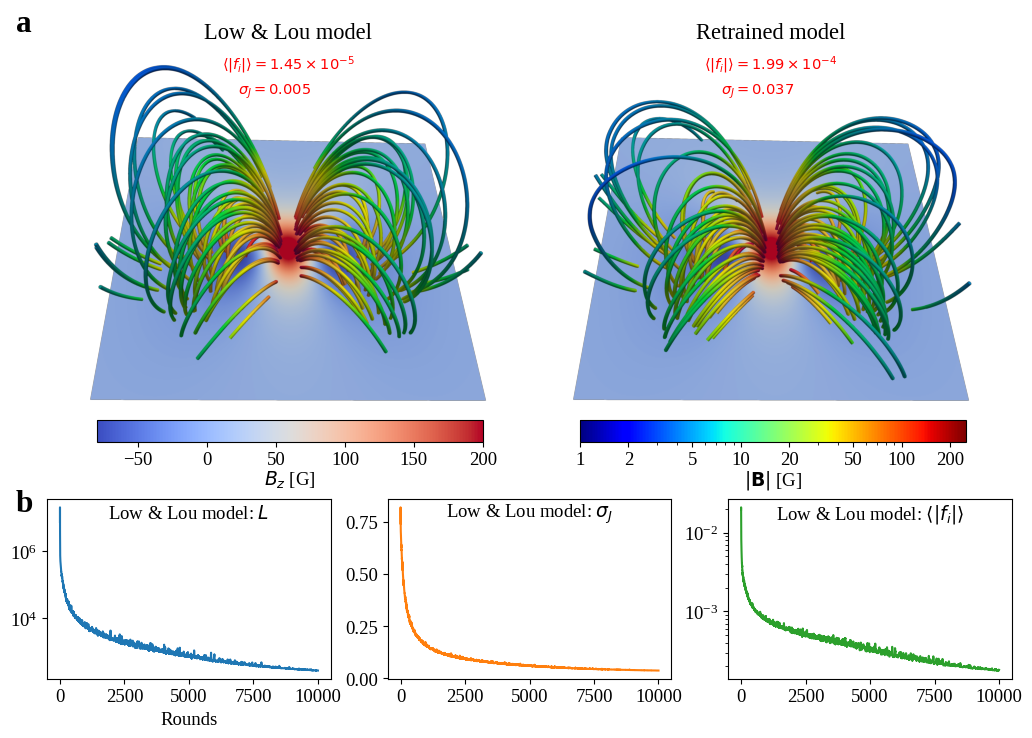

time: 6.57 s (started: 2025-04-22 20:31:33 +08:00)


In [23]:
zoom_factor = 1.5
plt.rcParams['font.size'] = 9.0*zoom_factor
plt.rcParams['font.family']='Liberation Serif'
A4_width = 8.3*zoom_factor
A4_length = 11.7*zoom_factor
golden_ratio = 0.618
img_ratio = LL_model_img.shape[0]/LL_model_img.shape[1]
cbar_ratio = 0.05

def get_axes_vertices(ax):
    vertices = [(0, 0), (1, 0), (1, 1), (0, 1)]
    transformed_vertices = [ax.transAxes.transform(v) for v in vertices]
    transformed_vertices = [fig.transFigure.inverted().transform(v) for v in transformed_vertices]
    return transformed_vertices

plot_height = A4_width*((img_ratio+cbar_ratio)/2+golden_ratio/3)
hspace_inches = plot_height*0.15
total_height = plot_height+hspace_inches*3
hspace_value = hspace_inches/total_height
fig = plt.figure(figsize=(A4_width, plot_height))
gs = gridspec.GridSpec(2, 1, height_ratios=[(img_ratio+cbar_ratio)/2, golden_ratio/3], hspace=0.2)

### panel 1 ###
gs1 = gridspec.GridSpecFromSubplotSpec(2, 2, subplot_spec=gs[0], wspace=0.00, hspace=0.00, height_ratios=[1, cbar_ratio/img_ratio])
ax = fig.add_subplot(gs1[0,0])
plt.imshow(LL_model_img, aspect='equal')
plt.axis('off')
plt.title('Low & Lou model')
plt.text(0.5,0.95, r'$\langle |f_i|\rangle=1.45\times 10^{-5}$', transform=plt.gca().transAxes,ha='center',va='center',
         fontsize=7.0*zoom_factor, color='r',
         fontdict={'family':'Times New Roman'}
        )
plt.text(0.5,0.88, r'$\sigma_J=0.005$        ', transform=plt.gca().transAxes,ha='center',va='center',
         fontsize=7.0*zoom_factor, color='r',
         fontdict={'family':'Times New Roman'}
        )

ax = fig.add_subplot(gs1[0,1])
plt.imshow(LL_retrained_img, aspect='equal')
plt.axis('off')
plt.title('Retrained model')
plt.text(0.5,0.95, r'$\langle |f_i|\rangle=1.99\times 10^{-4}$', transform=plt.gca().transAxes,ha='center',va='center',
         fontsize=7.0*zoom_factor, color='r',
         fontdict={'family':'Times New Roman'}
        )
plt.text(0.5,0.88, r'$\sigma_J=0.037$        ', transform=plt.gca().transAxes,ha='center',va='center',
         fontsize=7.0*zoom_factor, color='r',
         fontdict={'family':'Times New Roman'}
        )

ax3 = fig.add_subplot(gs1[1,0])
# plt.imshow(cbar1_array.transpose(1,0,2), aspect='equal')
# plt.axis('off')
cmap = plt.get_cmap('coolwarm')
norm = Normalize(vmin=-80, vmax=200)
cbar = ColorbarBase(ax3, cmap=cmap, norm=norm, orientation='horizontal')
cbar.set_label(r'$B_z$ [G]', labelpad=0)


# colorbar 2
ax4 = fig.add_subplot(gs1[1, 1])
cmap = plt.get_cmap('jet')
norm = LogNorm(vmin=1, vmax=250)
cbar2 = ColorbarBase(ax4, cmap=cmap, norm=norm, orientation='horizontal')

custom_ticks = [1,2,5,10,20,50,100,200]
cbar2.set_ticks(custom_ticks)

# 自定义刻度格式
def log_format(x, pos):
    return '{:.0f}'.format(x)

cbar2_formatter = ticker.FuncFormatter(log_format)
cbar2.formatter = cbar2_formatter
cbar2.update_ticks()

cbar2.set_label(r'$|\mathbf{B}|$ [G]', labelpad=0)

# 获取 colorbar 位置
pos3 = ax3.get_position()
pos4 = ax4.get_position()

# 手动调整 colorbars 的宽度和位置以增加间距，并使它们居中
cbar_width = 0.8*pos3.width
ax3.set_position([0.145+0.02, pos3.y0, cbar_width, pos3.height])  # 调整 ax3 的位置和宽度
ax4.set_position([0.533+0.02, pos4.y0, cbar_width, pos4.height])  # 调整 ax4 的位置和宽度

### panel 2 ###
gs2 = gridspec.GridSpecFromSubplotSpec(1, 3, subplot_spec=gs[1], wspace=0.2, hspace=0.00)
ax = fig.add_subplot(gs2[0])
plt.plot(LL_L_list, label='L', c='C0')
plt.yscale('log')
plt.text(0.5,0.92,'Low & Lou model: $L$', transform=plt.gca().transAxes,ha='center',va='center')
plt.xlabel('Rounds')

ax = fig.add_subplot(gs2[1])
plt.plot(LL_sJ_list, label='$\sigma_J$', c='C1')
plt.text(0.5,0.92,'Low & Lou model: $\sigma_J$', transform=plt.gca().transAxes,ha='center',va='center')

ax = fig.add_subplot(gs2[2])
plt.plot(LL_fi_list, label=r'$\left<\|f_i\|\right>$', c='C2')
plt.yscale('log')
plt.text(0.5,0.92,r'Low & Lou model: $\langle |f_i| \rangle$', transform=plt.gca().transAxes,ha='center',va='center')

xx = 0.10
ya = 0.925
yb = 0.341
fig.text(xx, ya, 'a', fontsize=15*zoom_factor, fontweight='bold', ha='left', va='top')
fig.text(xx, yb, 'b', fontsize=15*zoom_factor, fontweight='bold', ha='left', va='top')

plt.savefig('fig4.pdf', bbox_inches='tight', dpi=400)
plt.savefig('fig4.png', bbox_inches='tight', dpi=400)
plt.show()